In [ ]:
from dotenv import load_dotenv
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from models.TabTransformer import run_experiment as run_experiment_c, infer_tabtransformer as infer_tabtransformer_c
from models.qCLSTabTransformer import run_experiment as run_experiment_q, infer_tabtransformer as infer_tabtransformer_q
from utils.Preprocessor import preprocess_amex

%load_ext autoreload
%autoreload 2

In [ ]:
#Use .env file with Kaggle API Token to download AMEX dataset
load_dotenv()
os.environ["KAGGLE_API_TOKEN"] = os.getenv("KAGGLE_API_TOKEN")
path = kagglehub.competition_download("amex-default-prediction")
file = os.path.join(path, "train_data.csv")
data_all = pd.read_csv(file, nrows=1e6)
file = os.path.join(path, "train_labels.csv")
labels_all = pd.read_csv(file,nrows=1e6)

#Scrape all data associated with the a random n customers
customers = data_all["customer_ID"].drop_duplicates().sample(n=24000, random_state=42)
data_without_labels = data_all[data_all["customer_ID"].isin(customers)]
labels = labels_all[labels_all["customer_ID"].isin(customers)]
data = preprocess_amex(data_without_labels, labels)
frac_fraud = np.sum(data['Class'])/len(data['Class'])

print(f"Size of dataset: {len(data)}")
print(f"Number of features: {data.shape[1]}")
print(f"# of Frauds = {int(np.sum(data['Class']))}")
print(frac_fraud*100, '% fraud')

Size of dataset: 24000
Number of features: 228
# of Frauds = 6228
25.949999 % fraud


In [10]:
#Split data into fraud and non-fraud to build high concentration of fraud in small training dataset
fraud_data = data[data['Class'] == 1].sample(frac=1, random_state=42)
non_fraud_data = data[data['Class'] == 0].sample(frac=1, random_state=42)

fraud_scores_c = []
non_fraud_scores_c = []
fraud_scores_q = []
non_fraud_scores_q = []
inference_auprcs_c = []
inference_auprcs_q = []

train_sizes = [2000, 4000, 6000, 8000, 10000]

for train_size in train_sizes:

    print(f"Train Size: {train_size}")
    training_fraud = int(frac_fraud*train_size) #Use for AMEX
    data_subset = pd.concat([fraud_data[:training_fraud], non_fraud_data[:train_size - training_fraud]]).sample(frac=1, random_state=42) #Use for AMEX

    #Run classical experiment on small dataset
    model_c, test_results_c, test_df = run_experiment_c(data_subset, lr=3e-3)
    print(f'Classical model test AUPRC: {test_results_c["auprc"]}')

    #Run quantum experiment on small dataset
    model_q, test_results_q, test_df = run_experiment_q(data_subset, lr=3e-3)
    print(f'Quantum CLS model test AUPRC: {test_results_q["auprc"]}\n')

    #Gathers metrics for different inference sizes to see how well the models generalize
    inference_fraud = int(frac_fraud * 10000)
    inference_df = pd.concat([fraud_data[training_fraud:training_fraud + inference_fraud],
                                non_fraud_data[train_size - training_fraud:train_size - training_fraud + 10000 - inference_fraud]]
                                ).sample(frac=1, random_state=42) #Use for AMEX dataset

    #Classical model inference
    results = infer_tabtransformer_c(model_c, inference_df)
    fraud_scores_c.append(results['probs'][results['targets'] == 1])      #Collects scores for true fraud data
    non_fraud_scores_c.append(results['probs'][results['targets'] == 0])  #Collects scores for true non-fraud data
    inference_auprcs_c.append(results['auprc'])

    #Quantum model inference
    results = infer_tabtransformer_q(model_q, inference_df)
    fraud_scores_q.append(results['probs'][results['targets'] == 1])
    non_fraud_scores_q.append(results['probs'][results['targets'] == 0])
    inference_auprcs_q.append(results['auprc'])

Train Size: 2000
Classical model test AUPRC: 0.8994328939239814
Quantum CLS model test AUPRC: 0.8765194868673559

Train Size: 4000
Classical model test AUPRC: 0.8628922115159455
Quantum CLS model test AUPRC: 0.8148614274349696

Train Size: 6000
Classical model test AUPRC: 0.8729310901020039
Quantum CLS model test AUPRC: 0.8690587528818231

Train Size: 8000
Classical model test AUPRC: 0.8684550460123363
Quantum CLS model test AUPRC: 0.8560375388530449

Train Size: 10000
Classical model test AUPRC: 0.8438106209925693
Quantum CLS model test AUPRC: 0.8534753025479596



In [11]:
def plot_score_dist_c(index: int):
    print(f"Inference AUPRC: {inference_auprcs_c[index]}")
    plt.hist(fraud_scores_c[index], bins=30, alpha=0.5, density=True, label="Fraud")
    plt.hist(non_fraud_scores_c[index], bins=30, alpha=0.5, density=True, label="Non-Fraud")
    plt.axvline(model_c.threshold, linestyle="--", label=f"Threshold = {model_c.threshold:.3f}")
    plt.title(f"Score Distribution (Classical), Train Size: {train_sizes[index]}")
    plt.xlabel("Predicted Fraud Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

def plot_score_dist_q(index: int):
    print(f"Inference AUPRC: {inference_auprcs_q[index]}")
    plt.hist(fraud_scores_q[index], bins=30, alpha=0.5, density=True, label="Fraud")
    plt.hist(non_fraud_scores_q[index], bins=30, alpha=0.5, density=True, label="Non-Fraud")
    plt.axvline(model_q.threshold, linestyle="--", label=f"Threshold = {model_q.threshold:.3f}")
    plt.title(f"Score Distribution (Quantum), Train Size: {train_sizes[index]}")
    plt.xlabel("Predicted Fraud Probability")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

Inference AUPRC: 0.8599732022712137


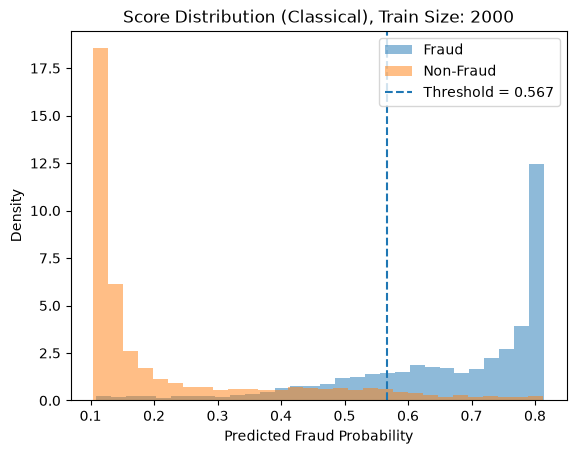

In [12]:
plot_score_dist_c(0)

Inference AUPRC: 0.851570694027051


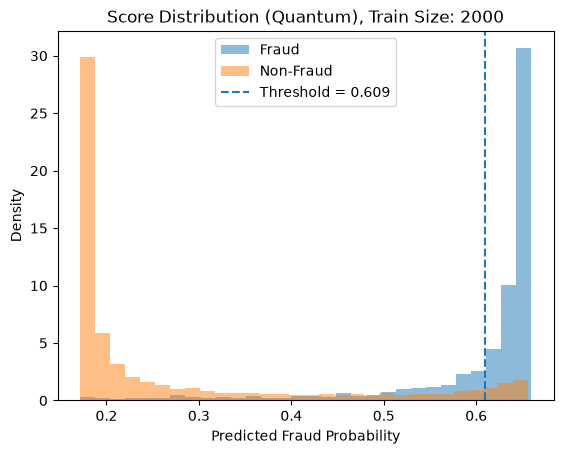

In [13]:
plot_score_dist_q(0)

Inference AUPRC: 0.8725854987276487


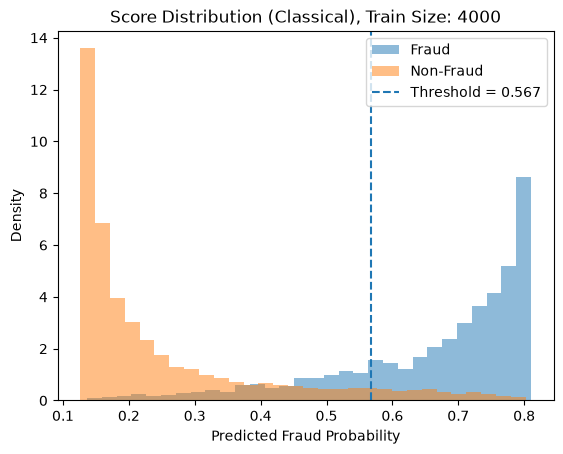

In [14]:
plot_score_dist_c(1)

Inference AUPRC: 0.8541272207370617


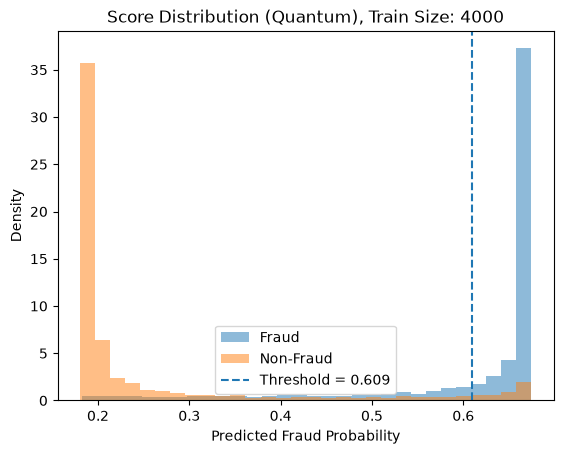

In [15]:
plot_score_dist_q(1)

Inference AUPRC: 0.8769337856463567


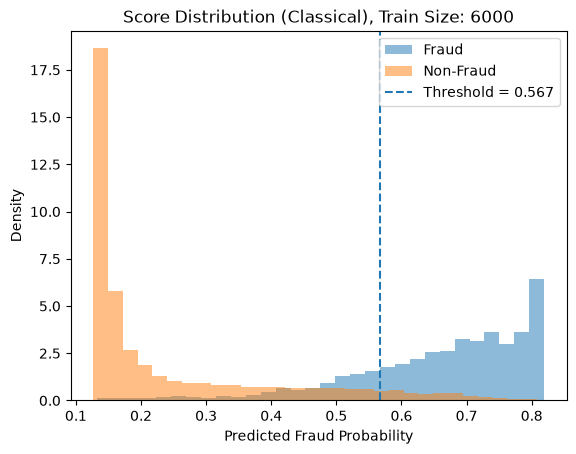

In [16]:
plot_score_dist_c(2)

Inference AUPRC: 0.8719395440553449


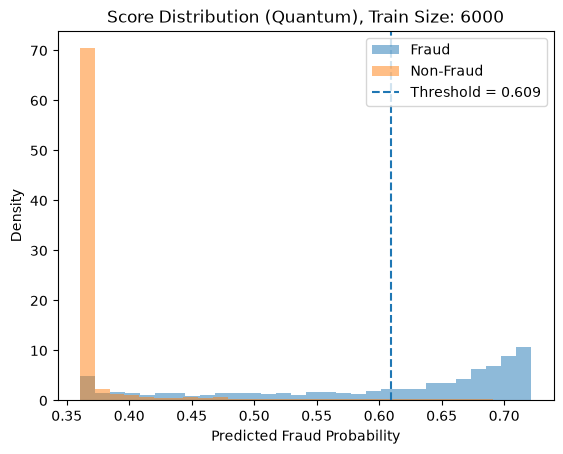

In [17]:
plot_score_dist_q(2)

Inference AUPRC: 0.8728418655702384


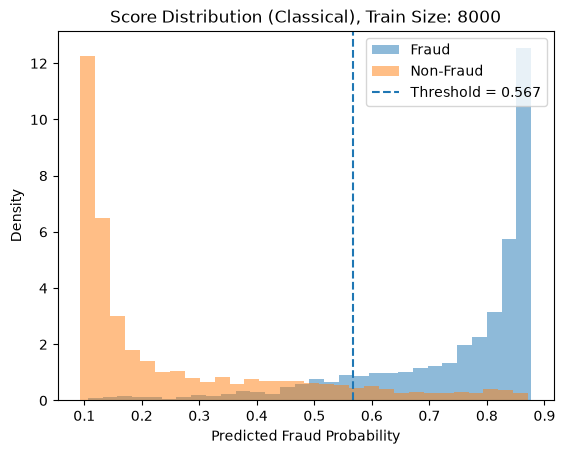

In [18]:
plot_score_dist_c(3)

Inference AUPRC: 0.8676279918934499


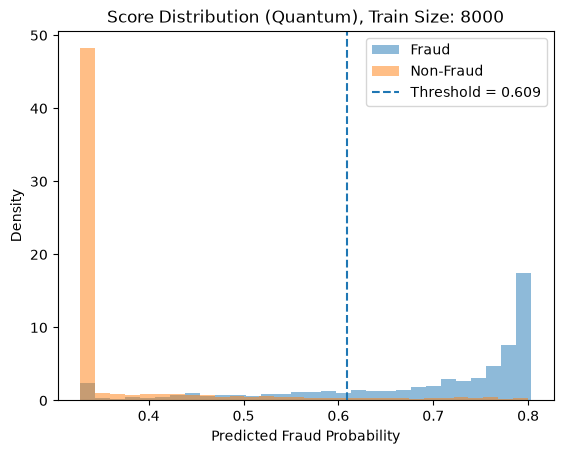

In [19]:
plot_score_dist_q(3)

Inference AUPRC: 0.8677457170579297


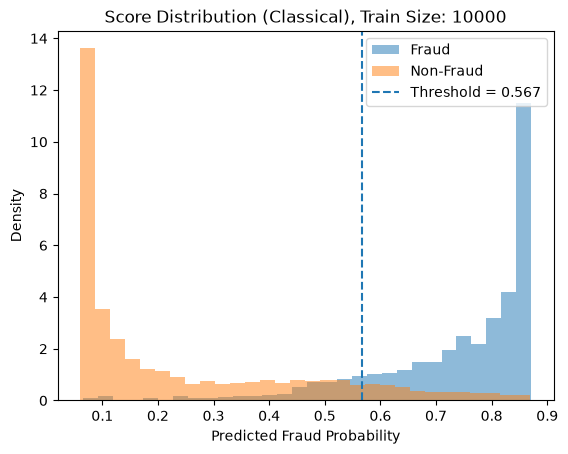

In [20]:
plot_score_dist_c(4)

Inference AUPRC: 0.8717295975375736


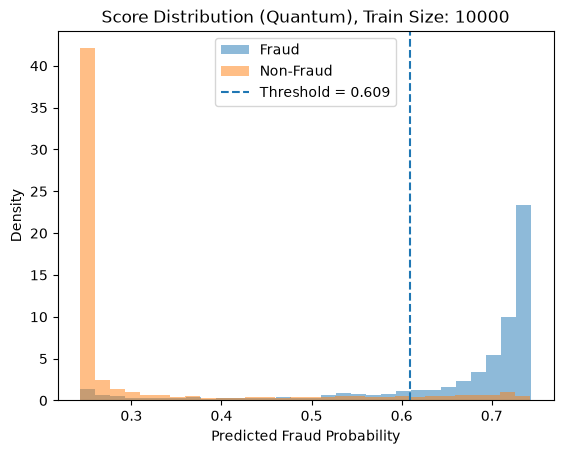

In [21]:
plot_score_dist_q(4)